In [1]:
# %pip install wordcloud

In [2]:
# !pip install contractions

In [3]:
# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
import nltk

import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Word Cloud
from wordcloud import WordCloud

# nltk.download('stopwords')
# nltk.download('wordnet')

In [4]:
# Loading the dataset
df = pd.read_csv("../datasets/twitter_training.csv",header = None)
df

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [5]:
df.columns = ['Tweet_id','Entity','Sentiment','Tweet']

In [6]:
df.head()

,Tweet_id,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
df.tail()

,Tweet_id,Entity,Sentiment,Tweet
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...
74681,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [8]:
df.shape

(74682, 4)

In [9]:
df.columns

Index(['Tweet_id', 'Entity', 'Sentiment', 'Tweet'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_id   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [11]:
df.isnull().sum()

Tweet_id       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [12]:
df.dropna(subset = ['Tweet'])

,Tweet_id,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [13]:
df.duplicated().sum()

np.int64(2700)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe(include = 'all')

,Tweet_id,Entity,Sentiment,Tweet
count,71982.000000,71982,71982,71656
unique,NaN,32,4,69491
top,NaN,TomClancysRainbowSix,Negative,It is not the first time that the EU Commissio...
freq,NaN,2344,21787,172
mean,6437.396307,NaN,NaN,NaN
std,3743.198550,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3199.000000,NaN,NaN,NaN
50%,6434.000000,NaN,NaN,NaN
75%,9607.000000,NaN,NaN,NaN


In [17]:
df = df[df['Sentiment'] != 'Irrelevant']
df.reset_index(drop = True, inplace = True)

In [18]:
df['Sentiment'].value_counts()

Sentiment
Negative    21787
Positive    19811
Neutral     17800
Name: count, dtype: int64

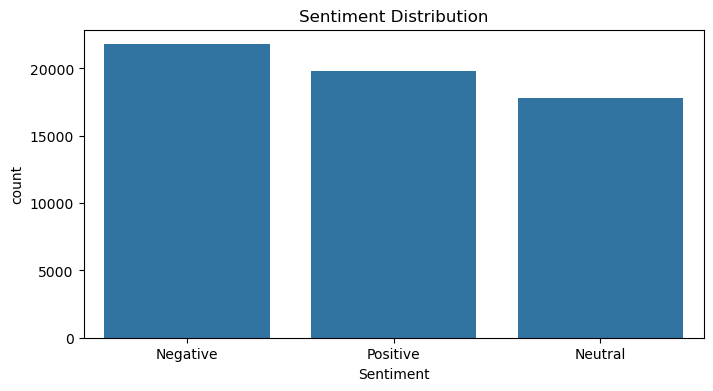

In [19]:
plt.figure(figsize = (8,4))
sns.countplot(x='Sentiment' , data = df , order = df['Sentiment'].value_counts().index)

plt.title('Sentiment Distribution')
plt.show()

### Observation

- The dataset contains customer opinions classified into different sentiment categories.
- The class distribution helps understand whether the dataset is balanced or imbalanced.
- This information is useful before training machine learning models.

## Text Preprocessing

Raw text often contains punctuation, capital letters, common words, and other unnecessary characters that do not help the machine learning model. In this phase, the text is cleaned and prepared using Natural Language Processing (NLP) techniques before feature extraction.

In [20]:
df['Original_tweet'] = df['Tweet']

In [21]:
df['Tweet'].head()

0    im getting on borderlands and i will murder yo...
1    I am coming to the borders and I will kill you...
2    im getting on borderlands and i will kill you ...
3    im coming on borderlands and i will murder you...
4    im getting on borderlands 2 and i will murder ...
Name: Tweet, dtype: object

In [22]:
def expand_contractions(text):
    return contractions.fix(text)
    
df = df.dropna(subset=["Tweet"])
df["Tweet"] = df["Tweet"].apply(expand_contractions)    

In [23]:
df['Tweet'] = df['Tweet'].str.lower()
df['Tweet'].head()

0    i am getting on borderlands and i will murder ...
1    i am coming to the borders and i will kill you...
2    i am getting on borderlands and i will kill yo...
3    i am coming on borderlands and i will murder y...
4    i am getting on borderlands 2 and i will murde...
Name: Tweet, dtype: object

In [24]:
df['Tweet'].isnull().sum()

np.int64(0)

In [25]:
# Remove rows with missing tweets
df = df.dropna(subset=['Tweet'])

print("Dataset Shape:", df.shape)

Dataset Shape: (59119, 5)


#### Remove Punctuation

Punctuation marks do not contribute to sentiment prediction, so they are removed from the text.

In [26]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))
    
df['Tweet'] = df['Tweet'].apply(remove_punctuation)

df['Tweet'].head()

0    i am getting on borderlands and i will murder ...
1    i am coming to the borders and i will kill you...
2    i am getting on borderlands and i will kill yo...
3    i am coming on borderlands and i will murder y...
4    i am getting on borderlands 2 and i will murde...
Name: Tweet, dtype: object

In [27]:
def remove_numbers(text):
    return re.sub(r'\d+', '' ,text)

df['Tweet'] = df['Tweet'].apply(remove_numbers)

In [28]:
def remove_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

df['Tweet'] = df['Tweet'].apply(remove_spaces)

#### Remove Stopwords

Stopwords are common words such as "the", "is", "am", and "are". Removing them helps the model focus on meaningful words.

In [29]:


stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Tweet'] = df['Tweet'].apply(remove_stopwords)
df['Tweet'].head()

0    getting borderlands murder
1           coming borders kill
2      getting borderlands kill
3     coming borderlands murder
4    getting borderlands murder
Name: Tweet, dtype: object

#### Lemmatization

Lemmatization converts words into their base form. For example, "running" becomes "run" and "studies" becomes "study".

In [30]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df['Tweet'] = df['Tweet'].apply(lemmatize_text)

df['Tweet'].head()

0    getting borderland murder
1           coming border kill
2      getting borderland kill
3     coming borderland murder
4    getting borderland murder
Name: Tweet, dtype: object

In [31]:
comparison = pd.DataFrame({
    "Original Tweet": df['Original_tweet'].head(5),
    "Cleaned Tweet": df['Tweet'].head(5)
})

comparison

,Original Tweet,Cleaned Tweet
0,im getting on borderlands and i will murder yo...,getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,getting borderland kill
3,im coming on borderlands and i will murder you...,coming borderland murder
4,im getting on borderlands 2 and i will murder ...,getting borderland murder


#### Observation

The tweet text has been cleaned by converting it to lowercase, removing punctuation, numbers, extra spaces, and stopwords, followed by lemmatization. The cleaned text is now ready for feature extraction using the TF-IDF Vectorizer.

## Feature Extraction (TF-IDF Vectorizer)

Machine learning algorithms cannot understand text directly. Therefore, the cleaned text is converted into numerical values using the **TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer**.

TF-IDF assigns higher importance to words that appear frequently in a document but less frequently across all documents. This helps the model focus on meaningful words while reducing the impact of very common words.

In [32]:
# create TF-IDF Vectorizer
tfidf = TfidfVectorizer()

In [33]:
df.head()

,Tweet_id,Entity,Sentiment,Tweet,Original_tweet
0,2401,Borderlands,Positive,getting borderland murder,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,coming border kill,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,getting borderland kill,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,coming borderland murder,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,getting borderland murder,im getting on borderlands 2 and i will murder ...


In [34]:
df['Tweet'].isnull().sum()

np.int64(0)

In [35]:
# Convert Cleaned Text into Numerical Features
x = tfidf.fit_transform(df['Tweet'])

In [36]:
# define target variable
y = df['Sentiment']

In [37]:
# check feature matrix shape
print("Feature matrix shape : ", x.shape)

Feature matrix shape :  (59119, 30523)


###### This means: 74,682 tweets and 25,000 unique words (features)

In [38]:
# get feature names
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['aa' 'aaa' 'aaaaaaaaaaaa' 'aaaaaaaaaaaaa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'
 'aaaaaaaaaaages' 'aaaaaaaaaages' 'aaarated' 'aagainst' 'aahqxwcz'
 'aajtak' 'aall' 'aamaavpjyc' 'aarogya' 'aaron' 'aaronrivin'
 'aaronrodgers' 'aat' 'aatjkpem' 'aatmanirbhar']


In [39]:
# count total feature
print('total_feature :' , len(feature_names))

total_feature : 30523


#### Observation

The cleaned text has been successfully converted into numerical features using the TF-IDF Vectorizer. Each unique word is treated as a feature, allowing machine learning models to process and learn from the text data effectively.

## Train-Test Split

Before training the machine learning models, the dataset is divided into training and testing sets.

- **Training Set (80%)** is used to train the model.
- **Testing Set (20%)** is used to evaluate the model's performance on unseen data.

This helps measure how well the model generalizes to new data.

In [40]:
# split the dataset into training and testing sets

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

In [41]:
print('Training Feature Shape : ',x_train.shape)
print('Testing Feature Shape : ',x_test.shape)
print('Training Labels Shape : ',y_train.shape)
print('Testing Labels Shape : ',y_test.shape)

Training Feature Shape :  (47295, 30523)
Testing Feature Shape :  (11824, 30523)
Training Labels Shape :  (47295,)
Testing Labels Shape :  (11824,)


In [42]:
print("Training Sample", len(y_train))
print("Training Sample", len(y_test))

Training Sample 47295
Training Sample 11824


#### Observation

The dataset has been successfully divided into training and testing sets using an 80:20 ratio. The training set will be used to train the machine learning models, while the testing set will be used to evaluate their performance on unseen data.

## Model Training

In this phase, two machine learning models are trained using the TF-IDF features.

The models used are:

- Naive Bayes
- Logistic Regression

Both models are trained using the training dataset and will later be evaluated using the testing dataset.

In [43]:
# Train Naive Bayes Model

# create Naive Bayes model 
nb_model = MultinomialNB()

# train model
nb_model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [44]:
# Predict Sentiment
nb_predictions = nb_model.predict(x_test)

In [45]:
# Create Logistic Regression model 
lr_model = LogisticRegression(max_iter = 1000)

# Train model 
lr_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
lr_predictions = lr_model.predict(x_test)

In [47]:
# display sample predictions

# Naive Bayes
print("Naive Bayes Predictions : ",nb_predictions[:10] )

# Logistic Regression
print("Logistic Regression Predictions : ",lr_predictions[:10] )

Naive Bayes Predictions :  ['Neutral' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Negative' 'Negative' 'Negative']
Logistic Regression Predictions :  ['Neutral' 'Positive' 'Positive' 'Positive' 'Negative' 'Negative'
 'Negative' 'Negative' 'Negative' 'Neutral']


In [48]:
# Compare Actual VS Predicted

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Naive Bayes": nb_predictions[:10],
    "Logistic Regression": lr_predictions[:10]
})

comparison

,Actual,Naive Bayes,Logistic Regression
0,Neutral,Neutral,Neutral
1,Positive,Positive,Positive
2,Positive,Positive,Positive
3,Positive,Positive,Positive
4,Negative,Negative,Negative
5,Positive,Negative,Negative
6,Positive,Negative,Negative
7,Neutral,Negative,Negative
8,Negative,Negative,Negative
9,Negative,Negative,Neutral


#### Observation

Both Naive Bayes and Logistic Regression models were successfully trained using the training dataset. Predictions were generated for the testing dataset and will be evaluated using different performance metrics.

## Model Evaluation

After training the models, their performance is evaluated using different evaluation metrics. These metrics help compare the effectiveness of Naive Bayes and Logistic Regression in classifying sentiments correctly.

In [49]:
# Evaluate Naive Bayes

# Accuracy
nb_accuracy = accuracy_score(y_test,nb_predictions)

# Precision
nb_precision = precision_score(y_test, nb_predictions, average = 'weighted')

# Recall
nb_recall = recall_score(y_test, nb_predictions, average = 'weighted')

# F1 Score
nb_f1_score = f1_score(y_test, nb_predictions, average = 'weighted')

# Display Results
print("Naive Bayes Performance")
print("-----------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1_score)

Naive Bayes Performance
-----------------------
Accuracy : 0.7771481732070366
Precision: 0.7904830881447054
Recall   : 0.7771481732070366
F1 Score : 0.772938223810965


Confusion Matrix : 
[[3929  131  344]
 [ 796 2068  590]
 [ 628  146 3192]]


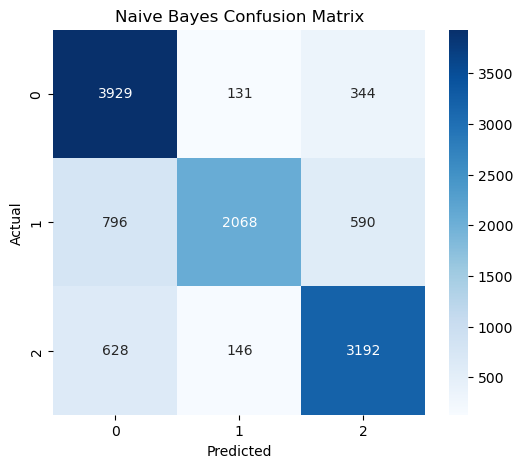

In [50]:
# confusion Matrix of Naive bayes
print("Confusion Matrix : ")
nb_confusion_matrix = confusion_matrix(y_test, nb_predictions)
print(nb_confusion_matrix)

plt.figure(figsize=(6,5))

sns.heatmap(
    nb_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# Classification Report

print("Classification Report - Naive Bayes\n")
print(classification_report(y_test, nb_predictions))

Classification Report - Naive Bayes

              precision    recall  f1-score   support

    Negative       0.73      0.89      0.81      4404
     Neutral       0.88      0.60      0.71      3454
    Positive       0.77      0.80      0.79      3966

    accuracy                           0.78     11824
   macro avg       0.80      0.77      0.77     11824
weighted avg       0.79      0.78      0.77     11824



In [53]:
# Evaluate Logistic Regression

# Accuracy
lr_accuracy = accuracy_score(y_test,lr_predictions)

# Precision
lr_precision = precision_score(y_test,lr_predictions , average = 'weighted')

# Recall 
lr_recall = recall_score(y_test,lr_predictions , average = 'weighted')

# F1 Score
lr_f1_score = f1_score(y_test, lr_predictions , average = 'weighted')

# Display Results
print("Logistic Regression Performance")
print("-------------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1_score)

Logistic Regression Performance
-------------------------------
Accuracy : 0.8066644113667117
Precision: 0.8065909087597797
Recall   : 0.8066644113667117
F1 Score : 0.806622790956759


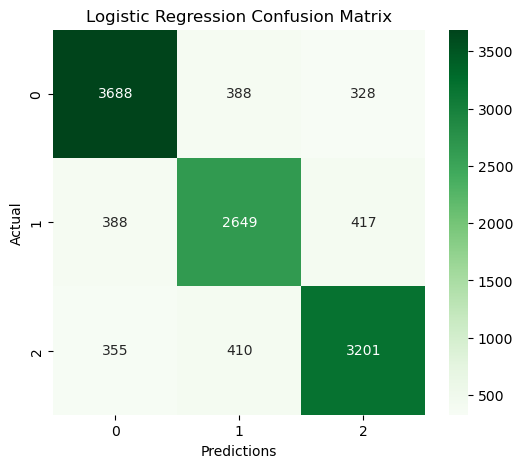

In [54]:
# Confusion Matrix
lr_confusion_matrix = confusion_matrix(y_test,lr_predictions)
plt.figure(figsize = (6,5))

sns.heatmap(lr_confusion_matrix, annot = True, fmt = 'd', cmap = 'Greens' )

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Actual")

plt.show()

In [55]:
# Classification Report

print("Classification Report - Logistic Regression\n")
lr_classification_report = classification_report(y_test,lr_predictions)
print(lr_classification_report)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

    Negative       0.83      0.84      0.83      4404
     Neutral       0.77      0.77      0.77      3454
    Positive       0.81      0.81      0.81      3966

    accuracy                           0.81     11824
   macro avg       0.80      0.80      0.80     11824
weighted avg       0.81      0.81      0.81     11824



In [56]:
comparison = pd.DataFrame({
    "Metric" : ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Naive Bayes" : [nb_accuracy, nb_precision, nb_recall, nb_f1_score],
    "Logistic Regression" : [lr_accuracy, lr_precision, lr_recall, lr_f1_score]
})

comparison

,Metric,Naive Bayes,Logistic Regression
0,Accuracy,0.777148,0.806664
1,Precision,0.790483,0.806591
2,Recall,0.777148,0.806664
3,F1 Score,0.772938,0.806623


#### Observation

Logistic Regression performed better than Naive Bayes on all evaluation metrics. With higher accuracy, precision, recall, and F1-score, it provided more accurate and balanced sentiment classification, making it the preferred model for this dataset.

## Data Visualization

Visualizations help in understanding the distribution of sentiments and the most frequently used words in each sentiment category.

In this phase, a sentiment distribution chart and WordClouds are created for Positive, Negative, and Neutral sentiments.

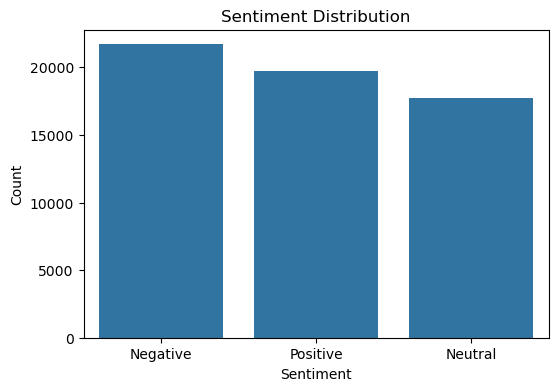

In [57]:
# Bar chart for Sentiments

plt.figure(figsize = (6,4))
sns.countplot(x='Sentiment', data = df, order = df['Sentiment'].value_counts().index)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

#### Observation

The bar chart shows the number of tweets belonging to each sentiment category. It helps understand the distribution of Positive, Negative, and Neutral sentiments in the dataset.

In [58]:
from wordcloud import STOPWORDS

custom_stopwords = STOPWORDS.union({
    "game",
    "games",
    "play",
    "playing",
    "one",
    "get",
    "getting",
    "new",
    "really",
    "people",
    "today",
    "time",
    "go",
    "know",
    "still","red","dead","wait","going"
})

In [59]:
# create word cloud function

def generate_wordcloud(text,title):
    wordcloud = WordCloud(width = 800, height = 400, background_color = 'white',stopwords=custom_stopwords).generate(" ".join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

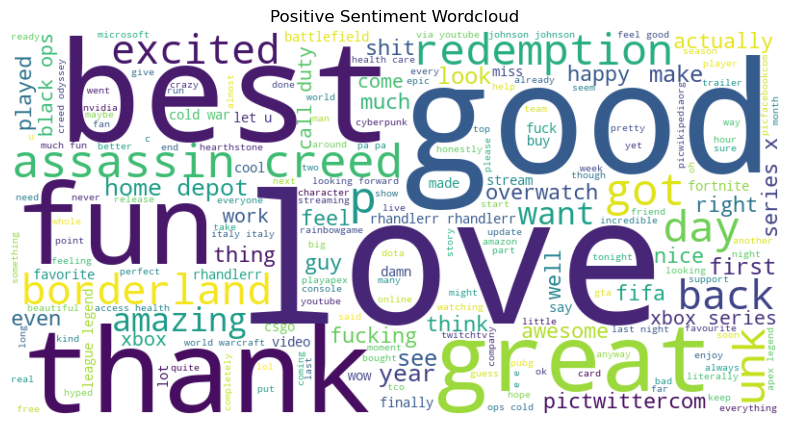

In [60]:
# Positive WordCloud
positive_wordcloud = df[df['Sentiment'] == 'Positive']['Tweet']
generate_wordcloud(positive_wordcloud, 'Positive Sentiment Wordcloud')

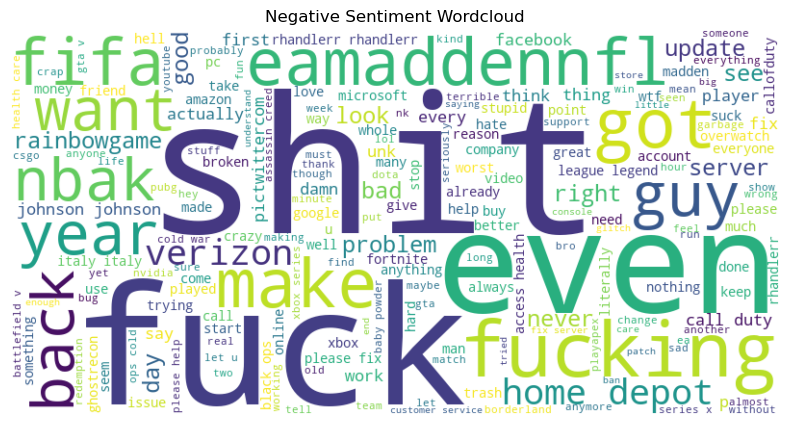

In [61]:
# Negative Wordcloud
negative_wordcloud = df[df['Sentiment'] == 'Negative']['Tweet']
generate_wordcloud(negative_wordcloud, 'Negative Sentiment Wordcloud')

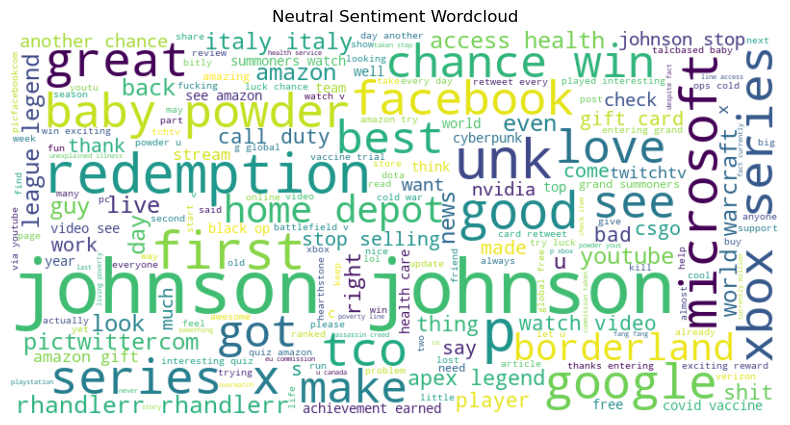

In [62]:
# Neutral WordCloud
neutral_wordcloud = df[df['Sentiment'] == 'Neutral']['Tweet']
generate_wordcloud(neutral_wordcloud, "Neutral Sentiment Wordcloud")

#### Observation

The WordClouds display the most frequently occurring words in each sentiment category. Larger words appear more often in the dataset, providing a quick visual understanding of common topics and opinions expressed by users.

## Error Analysis

Even the best machine learning models make some incorrect predictions. In this section, we identify a few misclassified examples to understand where the model struggled and discuss possible reasons for these errors.

In [63]:
# Create a dataframe for comparison (Logistic Regression)
results = pd.DataFrame({
    "Tweet" : df.loc[y_test.index, 'Original_tweet'],
    "Actual Sentiment" : y_test,
    "Predicted Sentiment" : lr_predictions
})

# find incorrect predictions
misclassified = results[results['Actual Sentiment'] != results['Predicted Sentiment']]

# display first five misclassified examples
misclassified.head()

,Tweet,Actual Sentiment,Predicted Sentiment
33394,PUBG is the best game to date.,Positive,Negative
43188,Damn call of duty did black black lives matter...,Positive,Negative
7654,"The Xbox Series X Has 60 FPS As 'Standard', Bu...",Neutral,Negative
31557,"In multiplayer mode, I don't see any player he...",Negative,Neutral
1646,ON BORDERLANDS TWO THERE IS A FUCKING DRAGON S...,Neutral,Negative


#### Error Analysis
The misclassified tweets suggest that the model struggles with context-dependent and ambiguous language. In some cases, incomplete sentences or limited context, such as "pubg best game date", made it difficult to identify the correct sentiment. Tweets containing words with strong emotional connotations, such as "damn" or "fucking", were often predicted as negative even when the overall sentiment was positive or neutral. Additionally, factual or gaming-related statements without clear emotional expressions were sometimes confused with neutral or negative sentiments. These examples highlight that while the model performs well on tweets with explicit sentiment, it can misclassify tweets that rely on context, slang, or informal language.

In [64]:
# compare model accuracy and select the best model 
print("Naive Bayes Accuracy :", round(nb_accuracy, 4))
print("Logistic Regression Accuracy :", round(lr_accuracy, 4))

if lr_accuracy > nb_accuracy:
    print("Best Model: Logistic Regression")
else:
    print("Best Model: Naive Bayes")

Naive Bayes Accuracy : 0.7771
Logistic Regression Accuracy : 0.8067
Best Model: Logistic Regression


## Conclusion

In this project, a sentiment analysis model was built to classify tweets into Positive, Negative, and Neutral sentiments.

The text data was cleaned using different preprocessing techniques and converted into numerical features using the TF-IDF Vectorizer. Two machine learning models, Naive Bayes and Logistic Regression, were trained and tested.

After comparing their performance, the model with better accuracy was selected as the final model, which is **Logistic Regression** .  This project shows that machine learning can effectively analyze text data and predict sentiments.

## Real-World Applications

Sentiment analysis can be used in many real-life situations, such as:

- Understanding customer reviews and feedback.
- Analyzing opinions shared on social media.
- Improving products and services based on customer feedback.
- Helping companies understand customer satisfaction.
- Supporting businesses in making better marketing decisions.

### Final Observation

The sentiment analysis model successfully classified tweets into Positive, Negative, and Neutral categories. The project demonstrates how Natural Language Processing and Machine Learning can be used to understand people's opinions from text data. It provides useful insights that can help businesses and organizations make better decisions.